In [2]:
import mysql.connector
import pandas as pd

In [7]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="*********",
    database="fraud_detection"
)

In [4]:
query = """
SELECT
    Class,
    COUNT(*) AS transaction_count
FROM creditcard
GROUP BY Class
ORDER BY Class;
"""

result = pd.read_sql(query, connection)

result

C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\3828785439.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql(query, connection)


,Class,transaction_count
0,0,284315
1,1,492


In [5]:
query = """
SELECT
    Class,
    COUNT(*) AS transaction_count,
    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM creditcard),
        4
    ) AS percentage
FROM creditcard
GROUP BY Class
ORDER BY Class;
"""

df_class = pd.read_sql(query, connection)

df_class

C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\478657317.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_class = pd.read_sql(query, connection)


,Class,transaction_count,percentage
0,0,284315,99.8273
1,1,492,0.1727


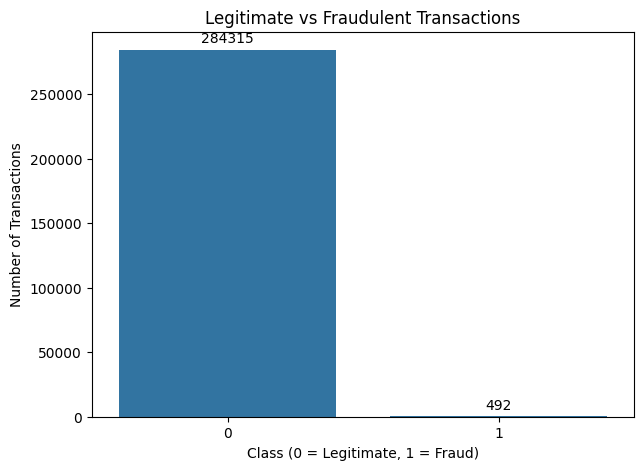

In [9]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=df_class,
    x="Class",
    y="transaction_count"
)

# Show count on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

In [10]:
query = """
SELECT
    COUNT(*) AS total_rows,
    SUM(Time IS NULL) AS missing_time,
    SUM(Amount IS NULL) AS missing_amount,
    SUM(Class IS NULL) AS missing_class
FROM creditcard;
"""

df_missing = pd.read_sql(query, connection)

df_missing

C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\3371499004.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_missing = pd.read_sql(query, connection)


,total_rows,missing_time,missing_amount,missing_class
0,284807,0.0,0.0,0.0


In [11]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT
        Time, V1, V2, V3, V4, V5, V6, V7, V8, V9,
        V10, V11, V12, V13, V14, V15, V16, V17, V18, V19,
        V20, V21, V22, V23, V24, V25, V26, V27, V28,
        Amount, Class
    ) AS unique_rows
FROM creditcard;
"""

df_duplicates = pd.read_sql(query, connection)

df_duplicates

C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\344421040.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_duplicates = pd.read_sql(query, connection)


,total_rows,unique_rows
0,284807,283726


In [12]:
query = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT
        Time, V1, V2, V3, V4, V5, V6, V7, V8, V9,
        V10, V11, V12, V13, V14, V15, V16, V17, V18, V19,
        V20, V21, V22, V23, V24, V25, V26, V27, V28,
        Amount, Class
    ) AS unique_rows
FROM creditcard;
"""

duplicate_check = pd.read_sql(query, connection)

duplicate_check["duplicate_rows"] = (
    duplicate_check["total_rows"]
    - duplicate_check["unique_rows"]
)

duplicate_check

C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\1312238102.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  duplicate_check = pd.read_sql(query, connection)


,total_rows,unique_rows,duplicate_rows
0,284807,283726,1081


In [13]:
query = """
CREATE TABLE IF NOT EXISTS creditcard_clean AS
SELECT DISTINCT *
FROM creditcard;
"""

cursor = connection.cursor()
cursor.execute(query)
connection.commit()

print("Cleaned table created successfully!")

Cleaned table created successfully!


In [14]:
query = """
SELECT COUNT(*) AS cleaned_rows
FROM creditcard_clean;
"""

cleaned_count = pd.read_sql(query, connection)

cleaned_count

C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\718641226.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cleaned_count = pd.read_sql(query, connection)


,cleaned_rows
0,283726


Verify that the fraud records are still present

In [15]:
query = """
SELECT
    Class,
    COUNT(*) AS transaction_count
FROM creditcard_clean
GROUP BY Class
ORDER BY Class;
"""

df_clean_class = pd.read_sql(query, connection)

df_clean_class

C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\3999743009.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_clean_class = pd.read_sql(query, connection)


,Class,transaction_count
0,0,283253
1,1,473


In [16]:
query = """
SELECT *
FROM creditcard_clean;
"""

df = pd.read_sql(query, connection)

print("Cleaned data loaded successfully!")
print("Shape:", df.shape)

C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\4146716330.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Cleaned data loaded successfully!
Shape: (283726, 31)


In [17]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  int64  
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 non-nu

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


In [20]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [21]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [22]:
class_summary = df["Class"].value_counts().reset_index()

class_summary.columns = ["Class", "Transaction_Count"]

class_summary["Percentage"] = (
    class_summary["Transaction_Count"]
    / len(df) * 100
)

class_summary

,Class,Transaction_Count,Percentage
0,0,283253,99.83329
1,1,473,0.16671


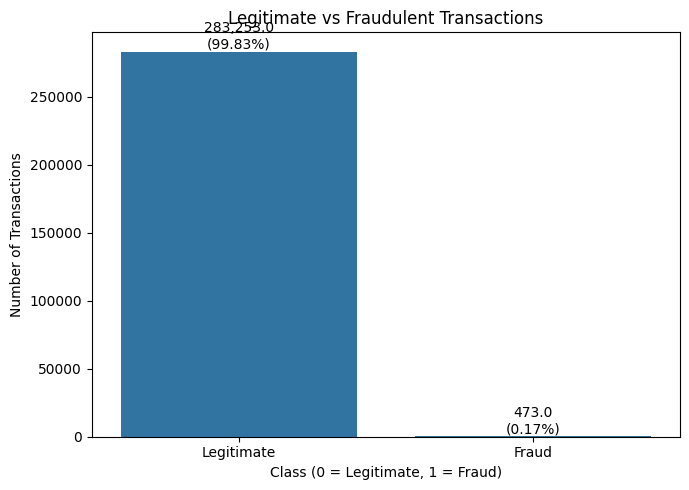

In [23]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=class_summary,
    x="Class",
    y="Transaction_Count"
)

for i, row in class_summary.iterrows():
    ax.text(
        i,
        row["Transaction_Count"],
        f'{row["Transaction_Count"]:,}\n({row["Percentage"]:.2f}%)',
        ha="center",
        va="bottom"
    )

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.tight_layout()
plt.show()

In [24]:
fraud_count = (df["Class"] == 1).sum()
total_count = len(df)

fraud_rate = (fraud_count / total_count) * 100

print("Total transactions:", total_count)
print("Fraudulent transactions:", fraud_count)
print(f"Fraud rate: {fraud_rate:.4f}%")

Total transactions: 283726
Fraudulent transactions: 473
Fraud rate: 0.1667%


In [25]:
amount_summary = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max"]
)

amount_summary

,count,mean,median,min,max
Class,,,,,
0,283253,88.413575,22.00,0.0,25691.16
1,473,123.871860,9.82,0.0,2125.87


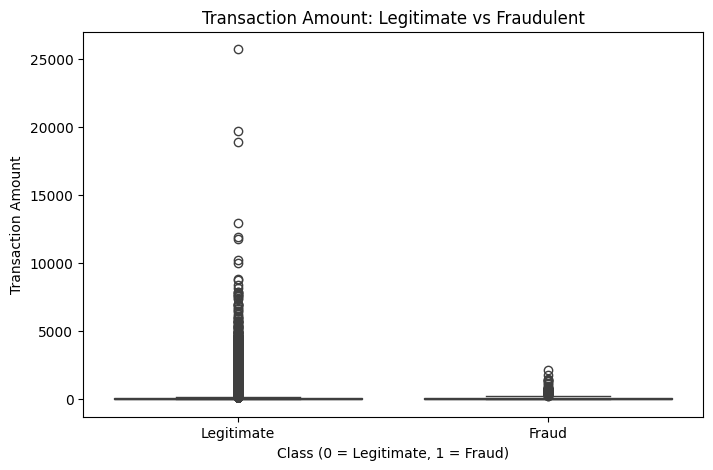

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount: Legitimate vs Fraudulent")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

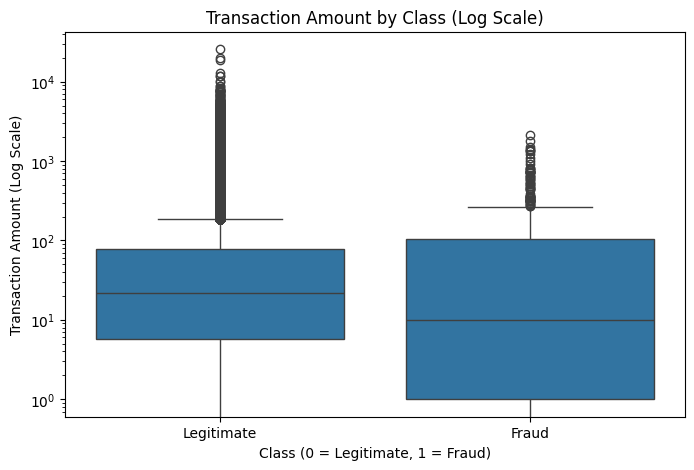

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.yscale("log")

plt.title("Transaction Amount by Class (Log Scale)")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount (Log Scale)")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

In [28]:
df["Time_Hours"] = df["Time"] / 3600

df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

df[["Time", "Time_Hours", "Hour"]].head()

,Time,Time_Hours,Hour
0,0,0.000000,0
1,0,0.000000,0
2,1,0.000278,0
3,1,0.000278,0
4,2,0.000556,0


In [29]:
fraud_by_hour = (
    df[df["Class"] == 1]
    .groupby("Hour")
    .size()
    .reset_index(name="Fraud_Count")
)

fraud_by_hour

,Hour,Fraud_Count
0,0,6
1,1,10
2,2,48
3,3,17
4,4,23
5,5,11
6,6,9
7,7,23
8,8,9
9,9,16


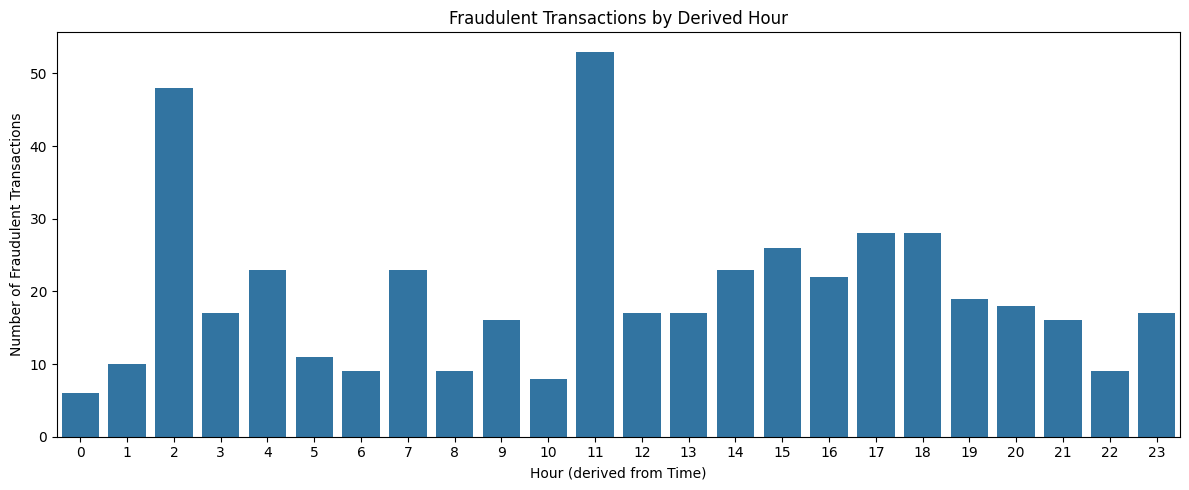

In [30]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=fraud_by_hour,
    x="Hour",
    y="Fraud_Count"
)

plt.title("Fraudulent Transactions by Derived Hour")
plt.xlabel("Hour (derived from Time)")
plt.ylabel("Number of Fraudulent Transactions")

plt.tight_layout()
plt.show()

In [31]:
hour_class = (
    df.groupby(["Hour", "Class"])
      .size()
      .unstack(fill_value=0)
)

hour_class["Fraud_Rate"] = (
    hour_class[1] / hour_class.sum(axis=1) * 100
)

hour_class

Class,0,1,Fraud_Rate
Hour,,,
0,7641,6,0.078462
1,4198,10,0.237643
2,3260,48,1.451028
3,3470,17,0.487525
4,2181,23,1.043557
5,2977,11,0.368139
6,4073,9,0.220480
7,7210,23,0.317987
8,10223,9,0.087959


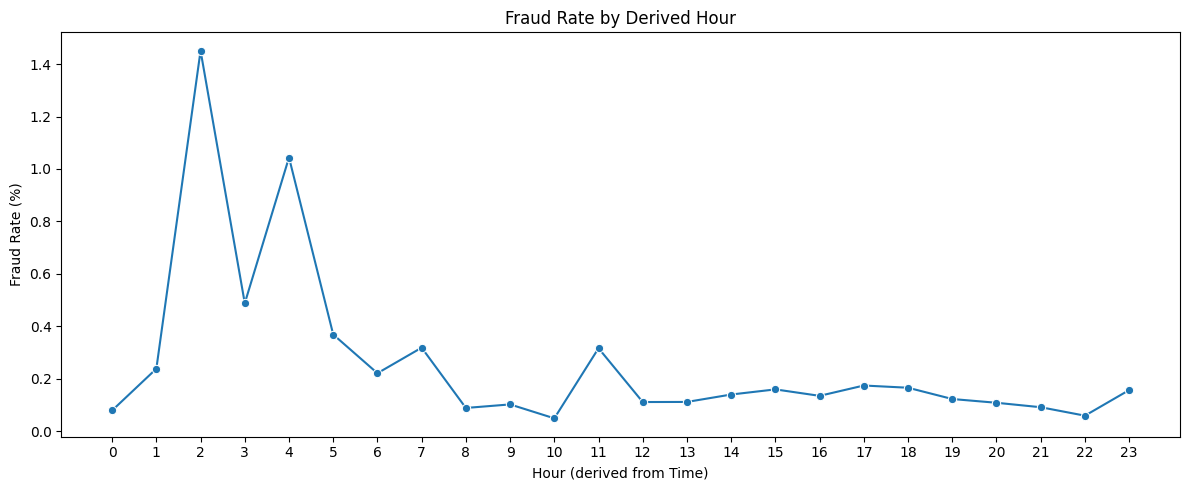

In [32]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hour_class.index,
    y=hour_class["Fraud_Rate"],
    marker="o"
)

plt.title("Fraud Rate by Derived Hour")
plt.xlabel("Hour (derived from Time)")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [33]:
v_features = [f"V{i}" for i in range(1, 29)]

v_summary = df.groupby("Class")[v_features].mean().T

v_summary.columns = ["Legitimate_Mean", "Fraud_Mean"]

v_summary["Absolute_Difference"] = (
    v_summary["Fraud_Mean"] - v_summary["Legitimate_Mean"]
).abs()

v_summary = v_summary.sort_values(
    "Absolute_Difference",
    ascending=False
)

v_summary.head(10)

,Legitimate_Mean,Fraud_Mean,Absolute_Difference
V14,0.011668,-6.835946,6.847614
V3,0.012853,-6.729599,6.742452
V17,0.010963,-6.463285,6.474249
V12,0.009476,-6.103254,6.112730
V10,0.007663,-5.453274,5.460937
V7,0.010447,-5.175912,5.186359
V1,0.013439,-4.498280,4.511719
V4,-0.010440,4.472591,4.483031
V16,0.007845,-4.000956,4.008801
V11,-0.006004,3.716347,3.722350


C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\1455044830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])
C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\1455044830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])
C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\1455044830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])
C:\Users\wadib\AppData\Local\Temp\ipykernel_14612\1455044830.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])
C:\Users\wadib\AppData\Local\Tem

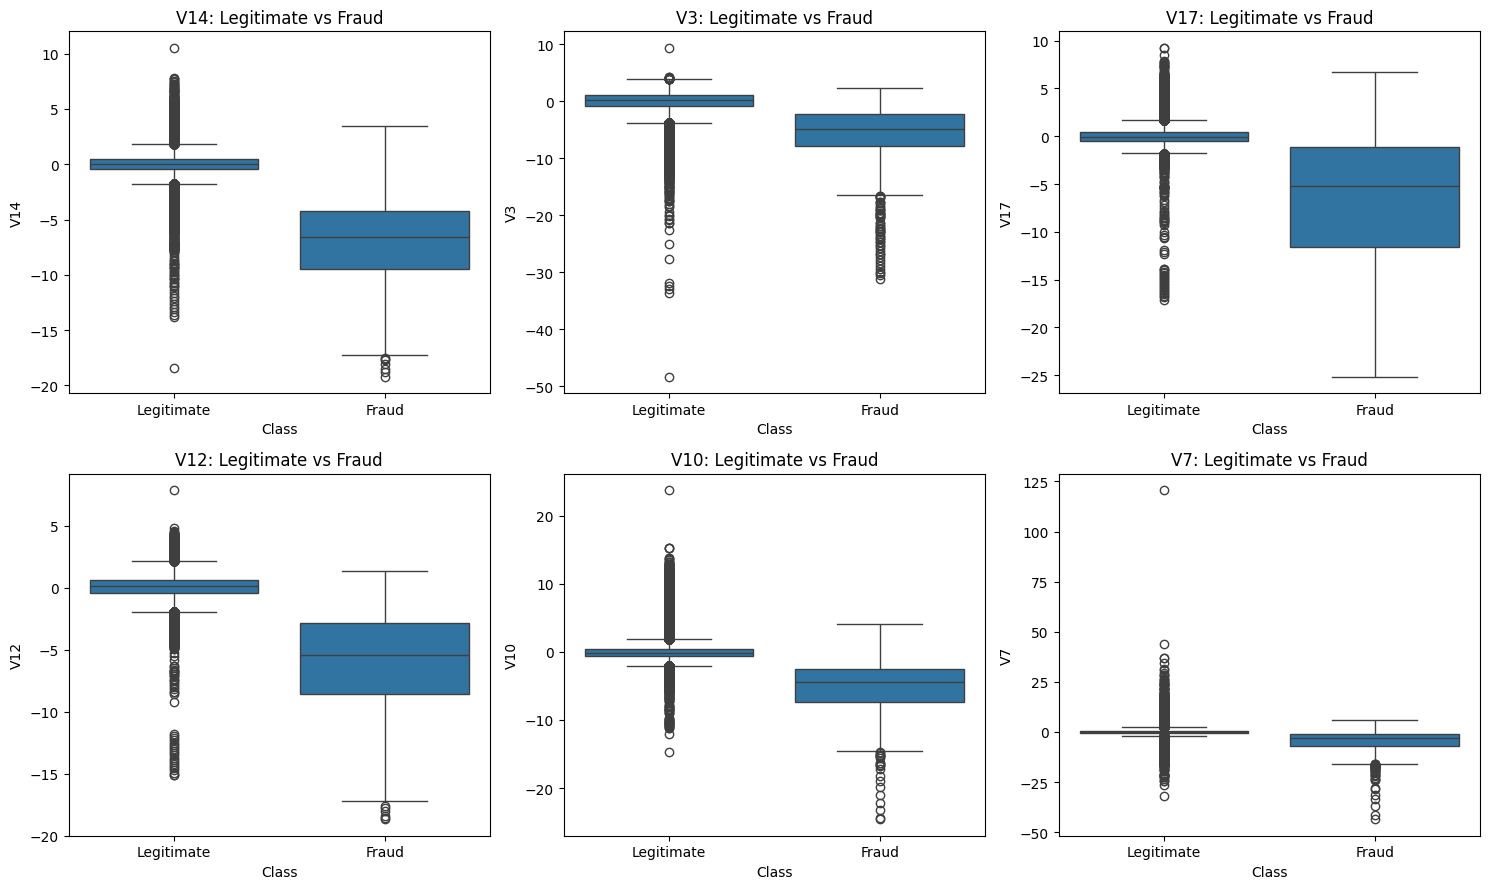

In [34]:
top_features = v_summary.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, feature in zip(axes.flat, top_features):
    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature}: Legitimate vs Fraud")
    ax.set_xlabel("Class")
    ax.set_ylabel(feature)
    ax.set_xticklabels(["Legitimate", "Fraud"])

plt.tight_layout()
plt.show()

In [35]:
correlation = df.corr(numeric_only=True)["Class"].sort_values(
    ascending=False
)

correlation

Class         1.000000
V11           0.149067
V4            0.129326
V2            0.084624
V19           0.033631
V8            0.033068
V21           0.026357
V27           0.021892
V20           0.021486
V28           0.009682
Amount        0.005777
V22           0.004887
V26           0.004265
V25           0.003202
V15          -0.003300
V13          -0.003897
V23          -0.006333
V24          -0.007210
Time         -0.012359
Time_Hours   -0.012359
Hour         -0.016740
V6           -0.043915
V5           -0.087812
V9           -0.094021
V1           -0.094486
V18          -0.105340
V7           -0.172347
V3           -0.182322
V16          -0.187186
V10          -0.206971
V12          -0.250711
V14          -0.293375
V17          -0.313498
Name: Class, dtype: float64

In [36]:
class_correlation = correlation.drop("Class")

strongest_positive = class_correlation.sort_values(
    ascending=False
).head(10)

strongest_negative = class_correlation.sort_values(
    ascending=True
).head(10)

print("Strongest positive correlations:")
display(strongest_positive)

print("\nStrongest negative correlations:")
display(strongest_negative)

Strongest positive correlations:


V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
Name: Class, dtype: float64


Strongest negative correlations:


V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V18   -0.105340
V1    -0.094486
V9    -0.094021
Name: Class, dtype: float64

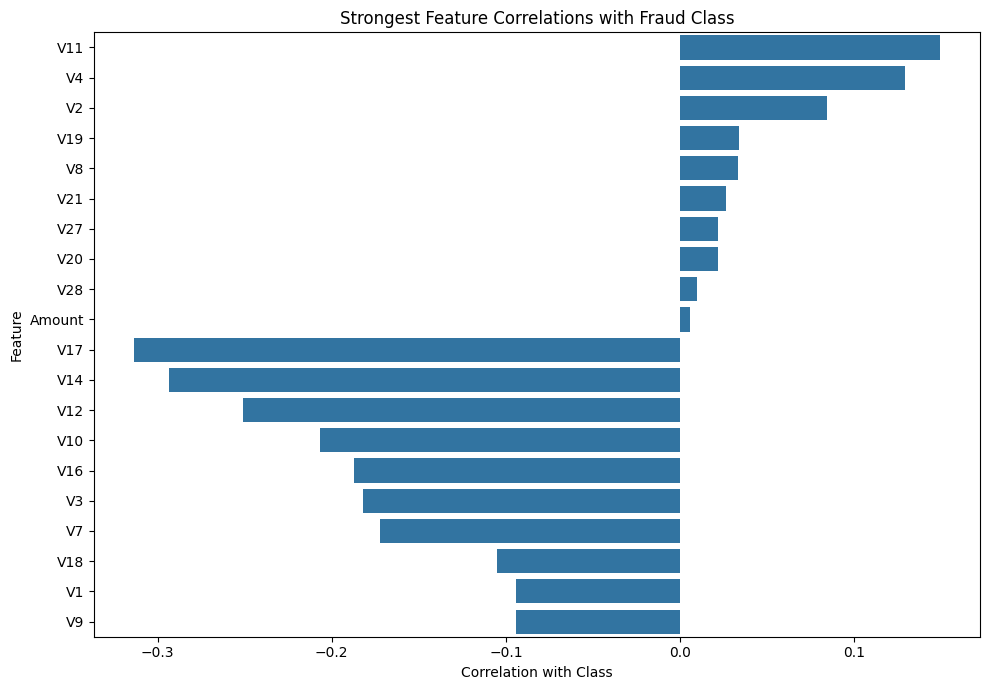

In [37]:
top_corr = pd.concat([
    strongest_positive,
    strongest_negative
]).drop_duplicates()

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Strongest Feature Correlations with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [38]:
df["Time_Hours"] = df["Time"] / 3600

df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

df["Log_Amount"] = np.log1p(df["Amount"])

df[["Time", "Time_Hours", "Hour", "Amount", "Log_Amount"]].head()

,Time,Time_Hours,Hour,Amount,Log_Amount
0,0,0.000000,0,149.62,5.014760
1,0,0.000000,0,2.69,1.305626
2,1,0.000278,0,378.66,5.939276
3,1,0.000278,0,123.50,4.824306
4,2,0.000556,0,69.99,4.262539


In [39]:
print("New features created:")
print(["Time_Hours", "Hour", "Log_Amount"])

New features created:
['Time_Hours', 'Hour', 'Log_Amount']


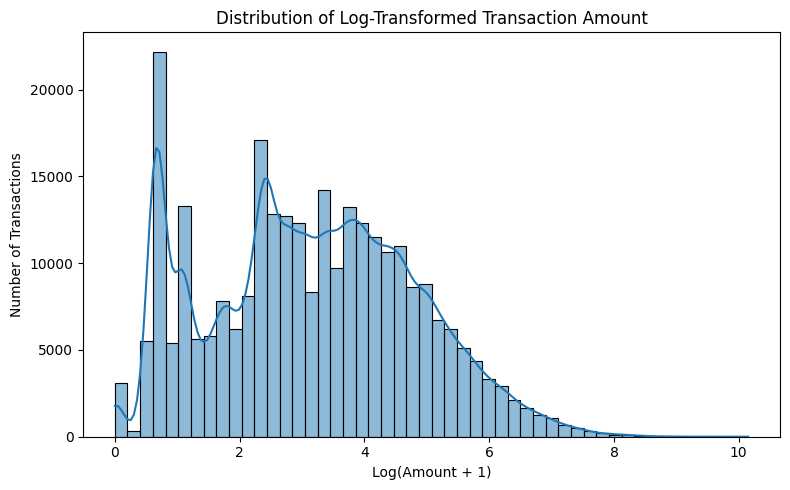

In [40]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Log_Amount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Log-Transformed Transaction Amount")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [41]:
feature_columns = (
    [f"V{i}" for i in range(1, 29)]
    + ["Amount", "Time_Hours", "Log_Amount"]
)

X = df[feature_columns]
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 31)
y shape: (283726,)


In [42]:
print("Legitimate:", (y == 0).sum())
print("Fraud:", (y == 1).sum())

Legitimate: 283253
Fraud: 473


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (226980, 31)
Testing set: (56746, 31)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [45]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

In [46]:
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [47]:
y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9750
Precision: 0.0558
Recall   : 0.8737
F1-Score : 0.1049
ROC-AUC  : 0.9654


In [49]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.10        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[55246  1405]
 [   12    83]]


<Figure size 700x600 with 0 Axes>

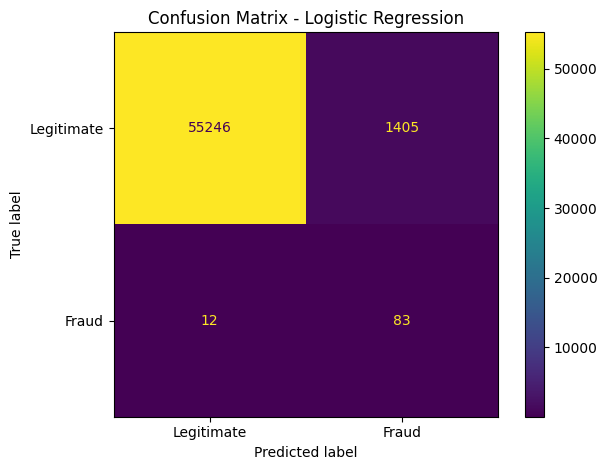

In [51]:
plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

In [52]:
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

metrics

,Metric,Score
0,Accuracy,0.975029
1,Precision,0.055780
2,Recall,0.873684
3,F1-Score,0.104864
4,ROC-AUC,0.965382
